In [4]:
import pandas as pd
from datetime import timedelta
import datetime as dt
import pickle
import os

In [5]:
import api_retrieval.markets.entsoe.functions as fu

In [6]:
monthly_capture_path = os.path.abspath('../../../data/entsoe/EM_monthly_capture_prices.pkl')
yearly_capture_path = os.path.abspath('../../../data/entsoe/EM_yearly_capture_prices.pkl')
monthly_capture_path

'c:\\Users\\mpy\\Python Unified\\data\\entsoe\\EM_monthly_capture_prices.pkl'

In [7]:
df = pd.read_excel("Capture prices european countries.xlsx")

df

,timestamp,Price,Wind Onshore Generation,Wind Onshore Capture Price,Wind Onshore Capture %,Solar Generation,Solar Capture Price,Solar Capture %,zone
0,1970-01-01 01:00:42.369,50.324661,47892428.00,46.236825,0.918771,12740026.0,53.108872,1.055325,Spain
1,1970-01-01 01:00:42.735,39.668449,47570347.00,34.668777,0.873964,12348461.0,39.332100,0.991521,Spain
2,1970-01-01 01:00:43.100,52.233312,47140553.00,50.723239,0.971090,13097794.0,51.807687,0.991851,Spain
3,1970-01-01 01:00:43.465,57.300820,48906680.00,53.101095,0.926707,12023772.0,59.342208,1.035626,Spain
4,1970-01-01 01:00:43.830,47.678462,52348144.00,45.651975,0.957497,14421349.0,48.578626,1.018880,Spain
...,...,...,...,...,...,...,...,...,...
83,1970-01-01 01:00:44.561,NaN,12035004.76,0.000000,NaN,5138616.0,0.000000,NaN,UK
84,1970-01-01 01:00:44.926,NaN,0.00,NaN,NaN,0.0,NaN,NaN,UK
85,1970-01-01 01:00:45.291,NaN,0.00,NaN,NaN,0.0,NaN,NaN,UK
86,1970-01-01 01:00:45.657,NaN,0.00,NaN,NaN,0.0,NaN,NaN,UK


In [8]:
zones = {
    'Spain': '10YES-REE------0',
    'Poland': '10YPL-AREA-----S',
    'Portugal': '10YPT-REN------W',
    'Italy North': '10Y1001A1001A73I',
    'Germany': '10Y1001A1001A82H',
    'Ireland': '10Y1001A1001A59C',  # No Solar for Ireland
    'France': '10YFR-RTE------C',
    'UK': '10YGB----------A',
    'Calabria':'10Y1001C--00096J'
    # 'Sweden' : '10YSE-1--------K'
}

techs = {
    'Wind Onshore': 'B19',
    'Solar': 'B16'
}

In [9]:
try:
    with open(monthly_capture_path, 'rb') as f:
        capture_prices_monthly_old = pickle.load(f)
        print('hi')
except FileNotFoundError:
    capture_prices_monthly_old = None

hi


In [10]:
# Time range - from last date downloaded to last month

start_dict_month = {}
end_dict_month = {}

if capture_prices_monthly_old is not None:
    for country in zones.keys():
        start_dict_month[country] = capture_prices_monthly_old[country].iloc[-1].name + pd.Timedelta(days=1)
        end_dict_month[country] = pd.Timestamp(dt.date.today().replace(day=1) , tz='UTC') - timedelta(hours=1)
    # start = pd.Timestamp(dt.date.today().replace(year=2010) , tz='UTC') 
else:
    for country in zones.keys():
        start_dict_month[country] = pd.Timestamp('2015-01-01', tz='UTC')
        end_dict_month[country] = pd.Timestamp(dt.date.today().replace(day=1) , tz='UTC') - timedelta(hours=1)

full_index_month = {country: pd.date_range(start=start_dict_month[country], end=end_dict_month[country], freq='h', tz='UTC') for country in zones.keys()}

In [11]:
try:
    with open(yearly_capture_path, 'rb') as f:
        capture_prices_yearly_old = pickle.load(f)
        print('Found!')
except FileNotFoundError:
    capture_prices_yearly_old = None


Found!


In [12]:
start_dict_yearly = {}
end_dict_yearly = {}

if capture_prices_yearly_old is not None:
    for country in zones.keys():
        start_dict_yearly[country] = capture_prices_yearly_old[country].iloc[-1].name + pd.Timedelta(days=1)
        end_dict_yearly[country] = pd.Timestamp(dt.date.today().replace(day=1) , tz='UTC') - timedelta(hours=1)
else:
    for country in zones.keys():
        start_dict_yearly[country] = pd.Timestamp('2019-01-01', tz='UTC')
        end_dict_yearly[country] = pd.Timestamp(dt.date.today().replace(day=1) , tz='UTC') - timedelta(hours=1)

full_index_year = {country: pd.date_range(start=start_dict_yearly[country], end=end_dict_yearly[country], freq='h', tz='UTC') for country in zones.keys()}

In [13]:
# Ejecutar descarga para cada país
price_data_year = {}
price_data_month = {}
for country, zone_code in zones.items():
    print(f"\n Downloading prices for {country}")
    df_month = fu.fetch_prices(zone_code, start_dict_month[country], end_dict_month[country], full_index_month[country])
    df_year = fu.fetch_prices(zone_code, start_dict_yearly[country], end_dict_yearly[country], full_index_year[country])
    price_data_month[country] = df_month
    price_data_year[country] = df_year


No price data retrieved.
No price data retrieved.

No price data retrieved.
No price data retrieved.

No price data retrieved.
No price data retrieved.

No price data retrieved.
No price data retrieved.

No price data retrieved.
No price data retrieved.

No price data retrieved.
No price data retrieved.

No price data retrieved.
No price data retrieved.

No price data retrieved.
No price data retrieved.

No price data retrieved.
No price data retrieved.


In [14]:
generation_data_month = fu.download_generation_all(zones,techs,full_index_month,start_dict_month, end_dict_month)
generation_data_year = fu.download_generation_all(zones,techs,full_index_year,start_dict_yearly, end_dict_yearly)


 Descargando generación para Spain

 Descargando generación para Poland

 Descargando generación para Portugal

 Descargando generación para Italy North

 Descargando generación para Germany

 Descargando generación para Ireland

 Descargando generación para France

 Descargando generación para UK

 Descargando generación para Calabria

 Descargando generación para Spain

 Descargando generación para Poland

 Descargando generación para Portugal

 Descargando generación para Italy North

 Descargando generación para Germany

 Descargando generación para Ireland

 Descargando generación para France

 Descargando generación para UK

 Descargando generación para Calabria


In [15]:
update_month = False
for country in zones.keys():
    if not (price_data_month[country].empty and generation_data_month[country].empty):
        update_month = True
        break
if update_month == False:
    monthly_capture_prices = pd.DataFrame()
else:
    monthly_capture_prices = fu.calculate_monthly_capture_prices(price_data_month, generation_data_month)

In [16]:
update_year = False

for country in zones.keys():
    if not (price_data_year[country].empty and generation_data_year[country].empty):
        update_year = True
        break
if update_year == False:
    yearly_capture_prices = pd.DataFrame()
else:
    yearly_capture_prices = fu.calculate_yearly_capture_prices(price_data_year, generation_data_year)

In [17]:
if capture_prices_monthly_old:
    capture_prices_monthly_combined = fu.merge_capture_data(capture_prices_monthly_old, monthly_capture_prices)
else:
    capture_prices_monthly_combined = monthly_capture_prices

In [18]:
if capture_prices_yearly_old:
    capture_prices_yearly_combined = fu.merge_capture_data(capture_prices_yearly_old, yearly_capture_prices)
else:
    capture_prices_yearly_combined = yearly_capture_prices

In [19]:
with open(monthly_capture_path, 'wb') as f:
    pickle.dump(capture_prices_monthly_combined, f)

with open(yearly_capture_path, 'wb') as f:
    pickle.dump(capture_prices_yearly_combined, f)

In [23]:
capture_prices_yearly_combined['Poland']

,Price,Wind Onshore Generation,Wind Onshore Capture Price,Wind Onshore Capture %,Solar Generation,Solar Capture Price,Solar Capture %
2019-12-31 00:00:00+00:00,212.284225,1.456540e+07,188.733211,0.889059,0.000000e+00,NaN,NaN
2020-12-31 00:00:00+00:00,46.656424,1.521144e+07,43.625798,0.935044,1.764729e+06,52.149822,1.117742
2021-12-31 00:00:00+00:00,87.034928,1.525252e+07,82.723093,0.950459,4.614562e+06,82.012709,0.942297
2022-12-31 00:00:00+00:00,166.714992,1.877622e+07,139.461891,0.836529,9.290400e+06,150.943710,0.905400
2023-12-31 00:00:00+00:00,111.656960,2.211356e+07,97.329616,0.871684,1.322361e+07,100.845238,0.903170
2024-12-31 00:00:00+00:00,96.251019,2.380379e+07,84.233941,0.875149,1.734514e+07,72.021862,0.748271
2025-12-31 00:00:00+00:00,104.301440,2.188898e+07,98.377677,0.943205,1.922863e+07,67.272647,0.644983
2026-12-31 00:00:00+00:00,130.183086,4.002720e+06,115.245643,0.885258,1.392088e+06,117.470386,0.902348


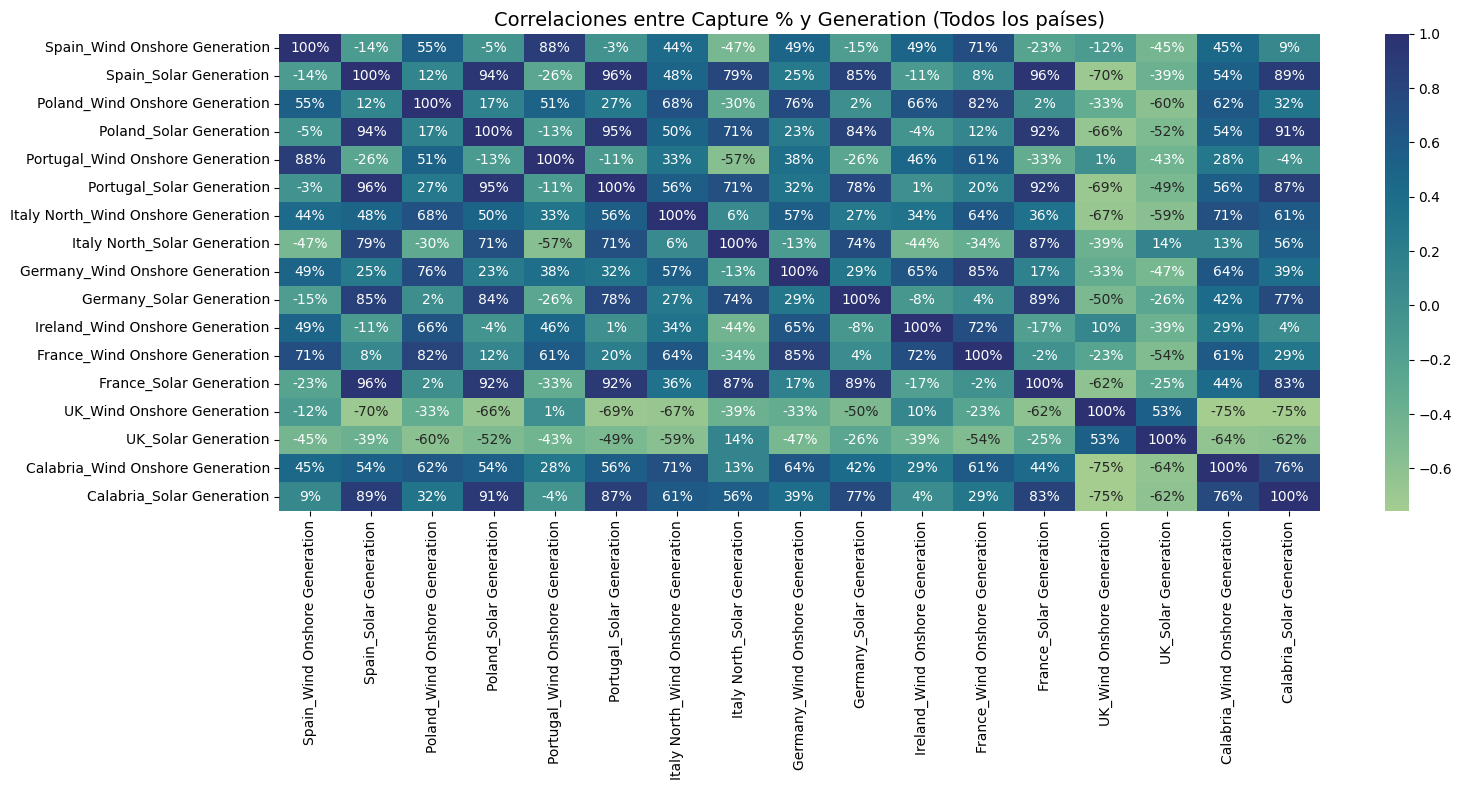

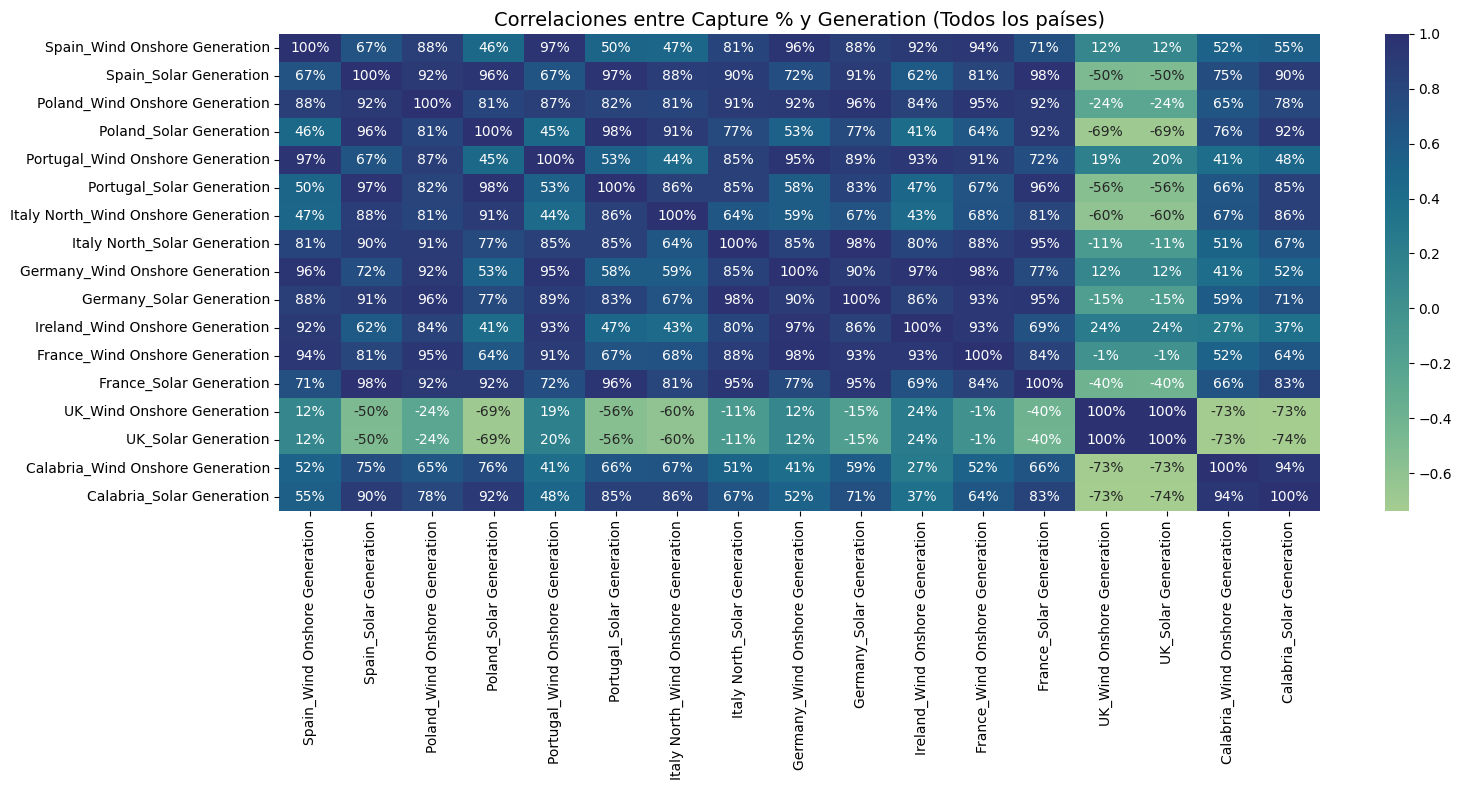

In [21]:
only_prices_monthly = {country: df[[col for col in df.columns if 'gene' in col.lower()]] for country, df in capture_prices_monthly_combined.items()}
only_prices_yearly = {country: df[[col for col in df.columns if 'gene' in col.lower()]] for country, df in capture_prices_yearly_combined.items()}

fu.plot_cross_country_correlation_heatmap(only_prices_monthly)
fu.plot_cross_country_correlation_heatmap(only_prices_yearly)